## New file to plot the valve characteristics

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

base_dir = os.path.dirname(os.path.abspath(""))
thesis_fig_folder = os.path.join(base_dir, 'Thesis report', 'figures_thesis')


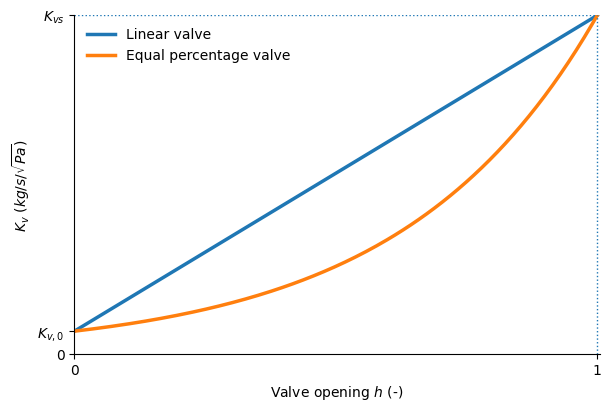

In [2]:
# -----------------------
# Ideal valve functions
# -----------------------

def linear_valve_func(h, Kvs, Kv0):
    return Kv0 + h * (Kvs - Kv0)


def equal_percentage_ideal(h, Kvs, Kv0):
    return (Kvs / Kv0) ** (h - 1) * Kvs


# -----------------------
# Parameters
# -----------------------

h_array = np.linspace(0, 1, 200)

Kvs = 0.003
Kv0 = Kvs / 15   # or Kvs/25 depending on your definition

Kv_linear = linear_valve_func(h_array, Kvs, Kv0)
Kv_equal = equal_percentage_ideal(h_array, Kvs, Kv0)

# -----------------------
# Plot
# -----------------------

fig, ax = plt.subplots(figsize=(6, 4), constrained_layout=True)

ax.plot(h_array, Kv_linear, lw=2.5, label='Linear valve')
ax.plot(h_array, Kv_equal, lw=2.5, label='Equal percentage valve')

ax.plot([0,1], [Kvs, Kvs], color='C0',ls = ':', lw=1)
ax.plot([1,1], [0, Kvs], color='C0', ls = ':', lw=1)

# Limits
ax.set_xlim(0, 1.005)
ax.set_ylim(0, Kvs)

# Labels
ax.set_xlabel(r'Valve opening $h$ (-)')
ax.set_ylabel(r'$K_v$ $(kg/s/\sqrt{Pa}$)')

# Clean ticks
ax.set_xticks([0, 1])
ax.set_xticklabels(['0', '1'])

ax.set_yticks([0, Kv0, Kvs])
ax.set_yticklabels(['0', r'$K_{v,0}$', r'$K_{vs}$'])

# Style
# ax.grid(alpha=0.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.legend(frameon=False)

plt.savefig(os.path.join(thesis_fig_folder, 'Kvplots_ideal.png'), dpi=150, bbox_inches='tight')
plt.show()

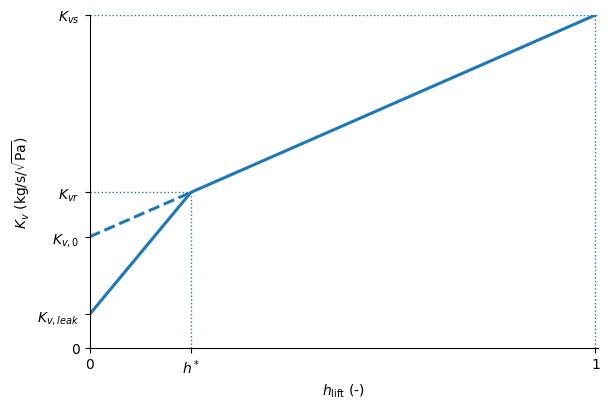

In [3]:
# -----------------------
# Parameters
# -----------------------
Kvs = 1
Kv0 = Kvs / 3
Kv_leak = Kvs / 10
h_star = 0.2

# -----------------------
# Ideal characteristics
# -----------------------
def linear_valve_func(h, Kvs, Kv0, Kvleak, h_star):
    def linear_ideal_func(h):
        return h * (Kvs - Kv0) + Kv0

    if h < h_star:
        Kv = Kvleak + h*(linear_ideal_func(h_star) - Kvleak)/h_star
    else:
        Kv = linear_ideal_func(h)
    return Kv

# -----------------------
# Data
# -----------------------
h_array = np.linspace(0, 1, 500)
Kv_lin_array = np.zeros(len(h_array))
Kv_ideal_lin_array = np.zeros(len(h_array))
for i,h in enumerate(h_array):
    Kv_lin_array[i] = linear_valve_func(h, Kvs, Kv0, Kv_leak, h_star)
    Kv_ideal_lin_array[i] = linear_valve_func(h, Kvs, Kv0, Kv_leak, 0)

# key point at h*
Kvr = linear_valve_func(h_star, Kvs, Kv0, Kv_leak, h_star)

# -----------------------
# Plot
# -----------------------
fig, ax = plt.subplots(figsize=(6.2, 4.2))

# Curves
ax.plot(h_array, Kv_lin_array, color='C0', lw=2.2, label='Linear')
ax.plot(h_array[h_array < h_star], Kv_ideal_lin_array[h_array < h_star], color='C0', ls = '--', lw=2.2)

# # Leakage / low-opening approximation (piecewise hint line)
# ax.plot([0, h_star], [Kv_leak,], color='C0', lw=1.2)

# Construction lines at h*
ax.plot([h_star, h_star], [0, Kvr], color='C0', ls=':', lw=1)
ax.plot([0, h_star], [Kvr, Kvr], color='C0', ls=':', lw=1)

ax.plot([0,1], [Kvs, Kvs], color='C0', ls = ':', lw=1)
ax.plot([1,1], [0, Kvs], color='C0', ls = ':', lw=1)

# -----------------------
# Text annotations
# -----------------------
# Clean ticks
ax.set_xticks([0,h_star, 1])
ax.set_xticklabels(['0', r'$h^*$', '1'])

ax.set_yticks([0, Kv_leak, Kv0, Kvr, Kvs])
ax.set_yticklabels(['0', r'$K_{v,leak}$', r'$K_{v,0}$', r'$K_{vr}$', r'$K_{vs}$'])

# -----------------------
# Axes styling
# -----------------------
ax.set_xlim(0, 1.005)
ax.set_ylim(0, Kvs)

ax.set_xlabel(r'$h_{\mathrm{lift}}$ (-)')
ax.set_ylabel(r'$K_v$ (kg/s/$\sqrt{\mathrm{Pa}}$)')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.savefig(os.path.join(thesis_fig_folder, 'Kvplots_linear_real.png'), dpi=150, bbox_inches='tight')
plt.tight_layout()
plt.show()